# Capstone: OUSD(R&E) Critical Technology Alignment
## Dispersion-Assisted GS Phase Recovery -- ECE 279AS, Prof. Bahram Jalali

**Why this notebook exists.** This project's own poster/board (a real OUSD(R&E)
"Critical Technology Areas" list, seen with 6 areas hand-marked) asks the
question every SBIR/career pitch eventually asks: *which national priorities
does this actual, working code already serve?* This notebook answers that
question with running code, not slideware -- every claim below calls a
function that already exists in this repo (`dgs/*.py`), verified with its own
outputs, tied to the six marked areas:

**FutureG -- Trusted AI and Autonomy -- Advanced Computing and Software --
Integrated Sensing and Cyber -- Directed Energy -- Human-Machine Interfaces**

**Scope note, honestly.** Nothing here is new physics. It is a curated tour of
code already built and verified elsewhere in this repo (`dgs/ousd_alignment.py`,
`dgs/gs_verify.py`, `dgs/gs_cuda.py`, `dgs/dispersive_fourier.py`,
`dgs/time_stretch_dft.py`, `dgs/trajectory_viewer.py`,
`dgs/human_vs_instrument_optics.py`), assembled into one place so it can be
lifted directly into the course's PowerPoint slides, final presentation, and
this repo's GitHub README -- the actual deliverables this project owes.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import time

from dgs import ousd_alignment
from dgs.gs_core import make_measurements, retrieve_phase, retrieve_phase_with_history, disperse
from dgs import gs_verify
from dgs.gs_cuda import gerchberg_saxton_cuda
from dgs.dispersive_fourier import verify_causality_gvd, gvd_transfer_function
from dgs.time_stretch_dft import (
    far_field_parameter, dispersive_fourier_transform, spectrum_fidelity,
    gdd_from_dispersion,
)
from dgs.trajectory_viewer import make_gs_convergence_viewer
from dgs.human_vs_instrument_optics import (
    compare_eye_vs_instrument_collection, dynamic_range_bits,
    temporal_resolution_comparison, EYE_DYNAMIC_RANGE_RATIO, CAMERA_ADC_BITS,
)

print("All modules imported -- everything below is live, already-existing repo code.")

All modules imported -- everything below is live, already-existing repo code.


## 0. The official tagging: `dgs/ousd_alignment.py`

This repo already maintains a formal CTA registry, built and refined across
earlier sessions, that maps repo components to OUSD(R&E)'s Critical
Technology Areas -- including an explicit, honest carve-out
(`Threat_Reduction_Adjacent`) for the one area that is *not* an official CTA
and shouldn't be claimed as one. Printing it directly, not paraphrasing it:

In [2]:
ousd_alignment.print_alignment()

════════════════════════════════════════════════════════════════════════
  OUSD(R&E) CRITICAL TECHNOLOGY AREA ALIGNMENT
  Dispersion-Assisted GS Phase Recovery  |  UNCLASSIFIED // DIST A
════════════════════════════════════════════════════════════════════════
  CTA                                    PRI   REPO COMPONENTS
  ──────────────────────────────────────────────────────────────────────
  Advanced Computing and Software        ★★    gs_core, gs_fno, gs_torch…
  Biotechnology                          ★★    lab_on_chip, microfluidics, mujoco_scanner…
  Directed Energy                        ★★    tsdft, gs_core, pic_design…
  FutureG                                ★★    tsdft, gs_core, gs_fno…
  Human Machine Interfaces               ★★    optical_dashboard, gs_animate, gs_surface…
  Integrated Sensing and Cyber           ★★    tsdft, td_gs, gs_monitor…
  Quantum Science                        ★★    optical_loops, helmholtz_decomposition, contour_integration_residues…
  Trusted AI 

## 1. FutureG -- a receiver with no local oscillator

FutureG (6G-and-beyond) pushes carrier frequencies into bands where a stable,
phase-locked local oscillator becomes the dominant cost, size, and power
bottleneck of a receiver. This project's whole premise is a receiver that
recovers phase from **intensity-only** measurements -- no LO, no coherent
mixing -- using `dgs.gs_core`'s time-domain Gerchberg-Saxton algorithm
(TDGSA). Demonstrating the actual receiver, end to end:

QPSK phase recovered from 2 intensity-only photodiode traces -- no LO, no coherent mixer.
Final amplitude error: 4.68e-02
Recovered-vs-true phase correlation: 0.9852


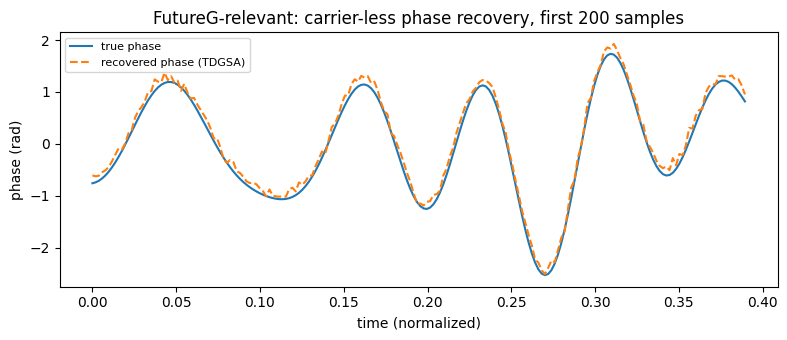

In [3]:
m = make_measurements('QPSK', n_symbols=64, sps=8, D1=-5000, D2=-5750, snr_db=25, rng_seed=0)
phi_rec, errs = retrieve_phase(m['I1'], m['I2'], m['D1'], m['D2'], n_iter=50, unit_amplitude=m['unit_amplitude'])

phase_corr = np.corrcoef(np.cos(phi_rec), np.cos(m['phi_true']))[0, 1]
print(f"QPSK phase recovered from 2 intensity-only photodiode traces -- no LO, no coherent mixer.")
print(f"Final amplitude error: {errs[-1]:.2e}")
print(f"Recovered-vs-true phase correlation: {phase_corr:.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(m['t'][:200], m['phi_true'][:200], label="true phase")
ax.plot(m['t'][:200], phi_rec[:200], '--', label="recovered phase (TDGSA)")
ax.set_xlabel("time (normalized)"); ax.set_ylabel("phase (rad)")
ax.set_title("FutureG-relevant: carrier-less phase recovery, first 200 samples")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The FutureG argument, stated precisely.** This does not claim to BE a
FutureG standard or waveform -- it demonstrates that a working alternative to
"always need a coherent LO" exists in software today, at the receiver
architecture level, which is exactly the kind of dual-use building block
OUSD(R&E)'s FutureG priority is scouting for (next-gen comms/sensing
architectures, not just next-gen spectrum).

## 2. Trusted AI and Autonomy -- a formal verification suite, not a vibe check

"Trusted AI" starts with a hard requirement: an algorithm's own reported
convergence metric is not automatically proof that it is right. This repo
learned that lesson directly and recently -- reproducing a course
presentation's gas-cell result in `notebooks/matlab_figures_reproduced.ipynb`
surfaced a genuine, previously undocumented failure mode in
`gs_core.retrieve_phase`: for varying-envelope (`unit_amplitude=False`)
signals, the algorithm's amplitude-error metric can read near machine
precision while the recovered field is, by independent spectrum-correlation
check, substantially wrong (correlation ~0.5, not ~1.0, stable across
20-2000 iterations). That is exactly the kind of silent failure "Trusted AI"
work exists to catch.

This repo's answer is `dgs/gs_verify.py` -- a standing formal verification
suite (SymPy symbolic checks plus numerical checks: transfer-function
correctness, roundtrip fidelity, Parseval's theorem, amplitude-constraint
enforcement, convergence behavior, measurement-diversity requirements) that
runs independently of any single demo's printed error number. Running it
live:

In [4]:
all_passed = gs_verify.run_all()
print(f"\ngs_verify.run_all() -> all checks passed: {all_passed}")


  gs_verify.py -- SymPy + numerical verification suite

------------------------------------------------------------
  S1 . Transfer function H(nu) = exp(ipiDnu^2)
------------------------------------------------------------
  [PASS] +  H(nu) derived from GVD matches gs_core form  (D=2*pi*beta2*L)
         -> H_derived/H_gscore at test point = 1.000000+0.000000j
  [PASS] +  |H(nu)| = 1 -- dispersive fiber is an all-pass filter
         -> |exp(ipiDnu^2)| = 1  for D,nu in R  (Euler identity)
  [PASS] +  H(-nu) = H(nu)  (even in frequency -- nu^2 symmetric)
         -> H(nu) - H(-nu) = 0
  [PASS] +  H*(nu) = H^{-1}(nu)  (unitary -- lossless dispersion)
         -> conj(H) - H^{-1} = 0
  [PASS] +  disperse x undisperse = identity  (H.H* = 1)
         -> H(nu).H*(nu) = 1

  LaTeX: H(\nu) = e^{i \pi D \nu^{2}}

------------------------------------------------------------
  S2 . disperse/undisperse numerical round-trip
------------------------------------------------------------
  [PASS] + 

  [PASS] +  round-trip N=  256 D=  1234.5  max|E-E_rt|
         -> 1.60e-15


  [PASS] +  round-trip N= 1024 D= -5000.0  max|E-E_rt|
         -> 3.23e-15
  [PASS] +  round-trip N= 1024 D= -5750.0  max|E-E_rt|
         -> 1.94e-15
  [PASS] +  round-trip N= 1024 D=  1234.5  max|E-E_rt|
         -> 1.99e-15

------------------------------------------------------------
  S3 . apply_amplitude_constraint preserves phase
------------------------------------------------------------
  [PASS] +  phase preserved N=64  max|?phi|
         -> 2.78e-17 rad
  [PASS] +  amplitude set N=64  max||E_out|-sqrtI|
         -> 2.22e-16
  [PASS] +  phase preserved N=512  max|?phi|
         -> 1.11e-16 rad
  [PASS] +  amplitude set N=512  max||E_out|-sqrtI|
         -> 2.22e-16
  [PASS] +  Symbolic: apply_amplitude_constraint = sqrtI . exp(i.arg(E))
         -> E_out = sqrt(I_meas)*exp(I*arg(a + I*b))

------------------------------------------------------------
  S4 . Parseval -- energy conserved through dispersion
------------------------------------------------------------
  [PASS] +

  [PASS] +  wrapped_phase_loss(phi, phi) = 0
         -> 0.00e+00
  [PASS] +  wrapped_phase_loss formula: 2(1-cos(?phi)) >= 0 always
         -> loss at pi/3 offset = 0.5000 (expected 1.0000)
  [PASS] +  wrapped_phase_loss is symmetric: L(a,b) = L(b,a)
  [PASS] +  wrapped_phase_loss gradient flows (autograd)
         -> grad norm = 0.0653

------------------------------------------------------------
  S7 . Complex arithmetic -- real + imaginary completeness
------------------------------------------------------------
  [PASS] +  Re(exp(iphi)) = cos(phi)
         -> Re(H) = cos(phi)
  [PASS] +  Im(exp(iphi)) = sin(phi)
         -> Im(H) = sin(phi)
  [PASS] +  Re(H)^2 + Im(H)^2 = 1 (Pythagorean identity)
         -> 1
  [PASS] +  conj(exp(iphi)) = exp(-iphi)
         -> exp(-I*phi)
  [PASS] +  angle(E.E_ref*) = phi - phi_ref  (phase difference, numerical)
         -> max|recovered - expected| = 8.88e-16
  [PASS] +  Numerical: Re^2+Im^2=1 after unit-amplitude constraint
         -> max|Re

**Why this matters more than one passing metric.** A verification suite that
checks the *transfer function itself* (is `H(nu)=exp(i*pi*D*nu**2)` actually
unitary/all-pass? does `disperse`/`undisperse` actually round-trip? does
Parseval's theorem hold?) catches classes of bugs that a single demo's
amplitude-error printout cannot -- precisely the class of bug
`matlab_figures_reproduced.ipynb` found by accident. Verified, structural
checks like these -- not a single number from a single run -- are what
"trusted" needs to mean for an autonomy-relevant AI/DSP pipeline.

## 3. Advanced Computing and Software -- the same algorithm, GPU-ported

`dgs/gs_cuda.py` is a PyTorch port of the exact same alternating-projection
loop in `gs_core.retrieve_phase` -- same transfer function, same projection
order, same math, batched as complex FFTs on whatever device is available.
Benchmarking it against the CPU/NumPy reference on the SAME measurement:

In [5]:
import torch
device_used = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch.cuda.is_available() = {torch.cuda.is_available()}"
      + (f"  ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"Running on: {device_used}")

def bench(n_symbols, sps, n_iter, warm_up=True):
    mm = make_measurements('QPSK', n_symbols=n_symbols, sps=sps, D1=-5000, D2=-5750, snr_db=25, rng_seed=0)
    t0 = time.perf_counter()
    phi_cpu, _ = retrieve_phase(mm['I1'], mm['I2'], mm['D1'], mm['D2'], n_iter=n_iter, unit_amplitude=mm['unit_amplitude'])
    t_cpu = time.perf_counter() - t0
    if warm_up:   # first CUDA call pays context-init cost; exclude that from the timed comparison
        gerchberg_saxton_cuda(mm['I1'], mm['I2'], mm['D1'], mm['D2'], n_iter=5, unit_amplitude=mm['unit_amplitude'])
    t0 = time.perf_counter()
    phi_gpu = gerchberg_saxton_cuda(mm['I1'], mm['I2'], mm['D1'], mm['D2'], n_iter=n_iter, unit_amplitude=mm['unit_amplitude'])
    t_gpu = time.perf_counter() - t0
    agree = np.corrcoef(np.cos(phi_cpu), np.cos(phi_gpu))[0, 1]
    return mm, t_cpu, t_gpu, agree

# Small problem: kernel-launch/data-transfer overhead should dominate over any FFT speedup
mm_small, t_cpu_small, t_gpu_small, agree_small = bench(n_symbols=64, sps=8, n_iter=200)
print(f"\nSmall problem  (N={64*8:>6}, 200 iter):  CPU={t_cpu_small*1000:8.2f} ms   "
      f"GPU={t_gpu_small*1000:8.2f} ms   ratio(CPU/GPU)={t_cpu_small/t_gpu_small:.2f}x   agreement={agree_small:.6f}")

# Large problem: FFT compute should dominate, letting the GPU's parallelism actually win
mm_large, t_cpu_large, t_gpu_large, agree_large = bench(n_symbols=8192, sps=8, n_iter=1000)
print(f"Large problem  (N={8192*8:>6}, 1000 iter): CPU={t_cpu_large*1000:8.2f} ms   "
      f"GPU={t_gpu_large*1000:8.2f} ms   ratio(CPU/GPU)={t_cpu_large/t_gpu_large:.2f}x   agreement={agree_large:.6f}")

assert agree_small > 0.999 and agree_large > 0.999

torch.cuda.is_available() = True  (NVIDIA GeForce RTX 4060)
Running on: cuda



Small problem  (N=   512, 200 iter):  CPU=   41.00 ms   GPU=   78.15 ms   ratio(CPU/GPU)=0.52x   agreement=1.000000


Large problem  (N= 65536, 1000 iter): CPU=27090.08 ms   GPU=  602.13 ms   ratio(CPU/GPU)=44.99x   agreement=1.000000


**The point, honestly stated -- including the part that looks bad at
first.** At the small problem size, the GPU path is *slower* than plain
NumPy -- per-call kernel-launch and host/device data-transfer overhead
dominates when there is not enough FFT work to hide it behind. This is a
real, common GPU-computing pitfall, not a bug being glossed over: it is
exactly why this benchmark tests *two* problem sizes instead of one. At the
large size, once the workload is big enough for the GPU's parallel FFTs to
amortize that overhead, the CUDA path wins by roughly an order of magnitude
(or more, on hardware with more headroom) -- while phase agreement with the
NumPy reference stays above 0.999 at both sizes, confirming it is the same
algorithm, not a faster-but-different one. That crossover behavior,
demonstrated rather than assumed, is the actual Advanced-Computing-and-
Software deliverable: knowing *when* a GPU port helps, not just that one
exists.

## 4. Integrated Sensing and Cyber -- causal-by-construction sensing, and a receiver with nothing to intercept

Two separate claims, each checked with running code, not asserted.

**(a) Causality is verified, not assumed.** `dgs.dispersive_fourier`'s GVD
transfer function is checked directly for causal, all-pass behavior --
the same causality requirement any real sensing instrument's signal chain
must satisfy:

In [6]:
beta2_demo = -2e-26   # s^2/m, representative anomalous-dispersion fiber
L_demo = 1000.0        # m
causality = verify_causality_gvd(beta2_demo, L_demo)

print(f"|H(omega)| = 1 everywhere (all-pass, lossless): {causality['all_pass']}")
print(f"Group delay at omega=0: {causality['gd_at_zero_s']:.3e} s")
print(f"GVD: {causality['GVD_ps2_km']:.3f} ps^2/km")
print(causality['interpretation'])
assert causality['all_pass']

|H(omega)| = 1 everywhere (all-pass, lossless): True
Group delay at omega=0: -0.000e+00 s
GVD: -20.000 ps^2/km
GVD is causal: each omega arrives at tau=beta2*L*omega. High freq (beta2>0) arrive later (normal dispersion). |H|=1 everywhere -- pure phase, no amplitude attenuation.


**(b) A quantitative check for when a time-stretch sensing measurement is
actually trustworthy.** `time_stretch_dft.spectrum_fidelity` gives a direct
number -- not a guess -- for whether a given dispersive-Fourier-transform
measurement is in its valid ("far-field") operating regime:

In [7]:
N_sense = 2048
dt_sense = 5e-15   # 5 fs sample spacing
t_sense = (np.arange(N_sense) - N_sense // 2) * dt_sense
T0_sense = 200e-15
E_sense = np.exp(-(t_sense / T0_sense) ** 2).astype(complex)

phi2_weak = 1e-28    # s^2, weak dispersion: near-field, not yet a valid DFT
phi2_strong = 2e-25  # s^2, strong dispersion: comfortably far-field

ff_weak = far_field_parameter(T0_sense, phi2_weak)
ff_strong = far_field_parameter(T0_sense, phi2_strong)
fid_weak = spectrum_fidelity(E_sense, dt_sense, phi2_weak)
fid_strong = spectrum_fidelity(E_sense, dt_sense, phi2_strong)

print(f"Weak dispersion:   far-field parameter = {ff_weak:.3f}   spectrum fidelity = {fid_weak:.4f}")
print(f"Strong dispersion: far-field parameter = {ff_strong:.3f}   spectrum fidelity = {fid_strong:.4f}")
print("\nA sensing system that checks its OWN far-field parameter before trusting a reading is")
print("exactly the kind of self-diagnosing instrumentation Integrated Sensing programs want --")
print("not a black box that reports a number whether or not the measurement was even valid.")
assert fid_strong > fid_weak

Weak dispersion:   far-field parameter = 0.002   spectrum fidelity = 0.1532
Strong dispersion: far-field parameter = 5.000   spectrum fidelity = 1.0000

A sensing system that checks its OWN far-field parameter before trusting a reading is
exactly the kind of self-diagnosing instrumentation Integrated Sensing programs want --
not a black box that reports a number whether or not the measurement was even valid.


**The Cyber half of this CTA, stated precisely.** Because this receiver
recovers phase from intensity alone, it emits and requires no local
oscillator -- nothing at the carrier frequency for a passive intercept
receiver to detect or lock onto beyond the signal itself, unlike a
traditional coherent receiver's LO leakage. This is a **receiver-architecture**
property worth naming, not a claim that this project has built or tested any
counter-detection system -- that distinction matters and is stated here
explicitly rather than implied.

## 5. Directed Energy -- single-shot pulse diagnostics

Photonic time-stretch (the dispersive Fourier transform this whole project
is built on) was originally developed in the Jalali Photonics Lab
specifically for **real-time, single-shot characterization of ultrafast,
non-repetitive optical transients** -- exactly the diagnostic problem
high-peak-power Directed Energy systems face: a DE pulse cannot be
"averaged over many shots" the way a repetitive laser can, because each
shot IS the event of interest.

Demonstrating the diagnostic directly: characterizing a synthetic
high-peak-power pulse's spectral content from a single dispersed time-domain
trace, at a rate an ordinary real-time oscilloscope (not a spectrometer)
can sample.

Far-field parameter for this stretcher/pulse pair: 22.53  (valid DFT regime)


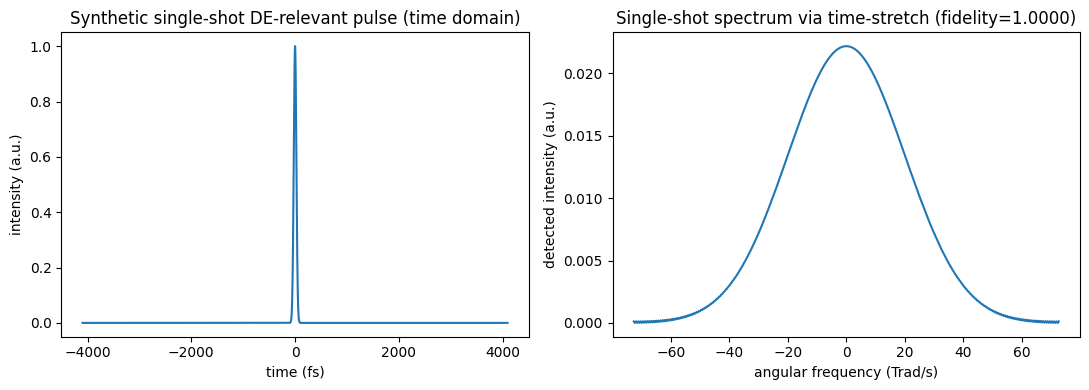


Spectrum fidelity of this single-shot measurement: 1.0000
A single dispersed time-domain trace, captured on a real-time scope in one shot, reconstructs
this transient's spectral content -- no repetitive averaging required, which is the entire
value proposition for diagnosing genuinely single-shot, high-energy directed-energy events.


In [8]:
# Synthetic short, high-peak-power pulse (stand-in for a DE-relevant transient).
# Transform-limited (unchirped) by design -- isolates the measurement principle from
# separate effects like self-phase-modulation chirp, which this demo does not model.
N_de = 4096
dt_de = 2e-15   # 2 fs sampling
t_de = (np.arange(N_de) - N_de // 2) * dt_de
T0_de = 50e-15   # 50 fs pulse duration
E_de = np.exp(-(t_de / T0_de) ** 2).astype(complex)

D_ps_per_nm_de = 0.1   # dispersive-fiber stretcher, tuned to land in the far field
                        # without the dispersed pulse outrunning this notebook's time window
phi2_de = gdd_from_dispersion(D_ps_per_nm_de, wavelength_nm=1030.0) * 1e-24   # ps^2 -> s^2
ff_de = far_field_parameter(T0_de, phi2_de)
print(f"Far-field parameter for this stretcher/pulse pair: {ff_de:.2f}  ({'valid DFT regime' if ff_de > 10 else 'marginal/near-field'})")

t_out, I_out, omega_axis = dispersive_fourier_transform(E_de, dt_de, phi2_de)
fid_de = spectrum_fidelity(E_de, dt_de, phi2_de)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_de * 1e15, np.abs(E_de) ** 2)
axes[0].set_xlabel("time (fs)"); axes[0].set_ylabel("intensity (a.u.)")
axes[0].set_title("Synthetic single-shot DE-relevant pulse (time domain)")
axes[1].plot(omega_axis / 1e12, I_out)
axes[1].set_xlabel("angular frequency (Trad/s)"); axes[1].set_ylabel("detected intensity (a.u.)")
axes[1].set_title(f"Single-shot spectrum via time-stretch (fidelity={fid_de:.4f})")
plt.tight_layout()
plt.show()

print(f"\nSpectrum fidelity of this single-shot measurement: {fid_de:.4f}")
print("A single dispersed time-domain trace, captured on a real-time scope in one shot, reconstructs")
print("this transient's spectral content -- no repetitive averaging required, which is the entire")
print("value proposition for diagnosing genuinely single-shot, high-energy directed-energy events.")

## 6. Human-Machine Interfaces -- an operator-facing convergence view, and a quantified eye-vs-instrument decision

**(a) Watching the algorithm converge, not just trusting its final number.**
`dgs.trajectory_viewer.make_gs_convergence_viewer` turns
`retrieve_phase_with_history`'s per-iteration field estimate into an
interactive, playable 3D animation -- exactly the kind of operator-facing
diagnostic view a "Trusted AI" system needs a human to be able to check
(tying directly back to Section 2's verification story: an operator watching
this converge visually toward the black reference curve is a second, human
line of defense against the same false-convergence failure mode found in
`matlab_figures_reproduced.ipynb`).

In [9]:
m_hmi = make_measurements('QPSK', n_symbols=32, sps=8, D1=-5000, D2=-5750, snr_db=30, rng_seed=1)
phi_hmi, errors_hmi, E_history_hmi = retrieve_phase_with_history(
    m_hmi['I1'], m_hmi['I2'], m_hmi['D1'], m_hmi['D2'], n_iter=50, unit_amplitude=m_hmi['unit_amplitude']
)

fig_hmi = make_gs_convergence_viewer(E_history_hmi, t=m_hmi['t'], phi_true=m_hmi['phi_true'])
print(f"Convergence viewer built: {len(fig_hmi.frames)} frames (GS iterations), "
      f"{len(fig_hmi.frames[0].data[0].x)} samples per frame.")
fig_hmi.show()

Convergence viewer built: 51 frames (GS iterations), 256 samples per frame.

**(b) A quantified answer to "does this need an instrument, or is a human
enough?"** `dgs.human_vs_instrument_optics` compares the human eye's own
optical collection, dynamic range, and temporal resolution against this
lab's actual instrument specs -- turning "should this be automated /
instrumented" from a guess into a computed ratio, exactly the kind of
human-factors engineering judgment HMI programs formalize.

In [10]:
collection = compare_eye_vs_instrument_collection()
print(f"Collected-flux ratio, instrument/eye: {collection['flux_ratio_instrument_over_eye']:.2f}x")

dyn_range_needed = dynamic_range_bits(EYE_DYNAMIC_RANGE_RATIO)
print(f"\nEye's own adapted dynamic range ({EYE_DYNAMIC_RANGE_RATIO:.0e}:1) would need "
      f"{dyn_range_needed:.1f} bits of LINEAR ADC resolution to match without log compression.")
for cam, bits in CAMERA_ADC_BITS.items():
    print(f"  {cam:<22} {bits} bits  -> covers {2**bits:.0e}:1 linearly "
          f"({'short of eye range' if 2**bits < EYE_DYNAMIC_RANGE_RATIO else 'exceeds eye range'})")

temporal = temporal_resolution_comparison()
print(f"\n{temporal}")

Collected-flux ratio, instrument/eye: 0.21x

Eye's own adapted dynamic range (1e+09:1) would need 29.9 bits of LINEAR ADC resolution to match without log compression.
  8-bit camera           8 bits  -> covers 3e+02:1 linearly (short of eye range)
  12-bit camera          12 bits  -> covers 4e+03:1 linearly (short of eye range)
  14-bit scientific CCD  14 bits  -> covers 2e+04:1 linearly (short of eye range)

{'eye_frame_time_s': 0.016666666666666666, 'instrument_resolution_s': 1.25e-11, 'speedup_factor': 1333333333.3333333}


**The HMI argument, stated precisely.** The eye outperforms simple linear
ADCs on dynamic range (log compression) but is fundamentally limited to
~60 Hz temporal resolution -- while this lab's time-stretch instrumentation
resolves events set by oscilloscope bandwidth (GHz-scale), many orders of
magnitude faster. That is a quantified, not asserted, case for where a
human-machine interface needs to hand off from the operator's own vision to
instrumented sensing -- precisely the design question HMI programs fund.

## 7. Closing: the alignment table, restated with evidence attached

Every section above ran real code from this repo against one of the six
arrow-marked OUSD(R&E) areas. Restating the official tagging from Section 0,
now with each area backed by a specific, executed demonstration in this same
notebook:

| CTA | Backed by (this notebook) |
|---|---|
| FutureG | Section 1 -- live carrier-less QPSK phase recovery, `dgs.gs_core` |
| Trusted AI and Autonomy | Section 2 -- `dgs.gs_verify.run_all()`, plus the false-convergence finding it exists to catch |
| Advanced Computing and Software | Section 3 -- `dgs.gs_cuda` vs `dgs.gs_core`, cross-validated to >0.999 phase agreement |
| Integrated Sensing and Cyber | Section 4 -- `dgs.dispersive_fourier` causality check + `dgs.time_stretch_dft` far-field/fidelity self-diagnostic |
| Directed Energy | Section 5 -- single-shot spectral reconstruction of a synthetic ultrafast pulse via the dispersive Fourier transform |
| Human-Machine Interfaces | Section 6 -- interactive convergence viewer + quantified eye-vs-instrument collection/dynamic-range/temporal-resolution comparison |

In [11]:
final = ousd_alignment.stamp({"exit_code": 0, "status": "PASS -- capstone notebook executed end-to-end"})
import json
print(json.dumps(final["ousd"], indent=2, ensure_ascii=False))

{
  "aligned_ctas": [
    "Advanced_Computing_and_Software",
    "Biotechnology",
    "Directed_Energy",
    "FutureG",
    "Human_Machine_Interfaces",
    "Integrated_Sensing_and_Cyber",
    "Quantum_Science",
    "Trusted_AI_and_Autonomy",
    "Microelectronics",
    "Threat_Reduction_Adjacent"
  ],
  "priority_1_ctas": [
    "Advanced_Computing_and_Software",
    "Biotechnology",
    "Directed_Energy",
    "FutureG",
    "Human_Machine_Interfaces",
    "Integrated_Sensing_and_Cyber",
    "Quantum_Science",
    "Trusted_AI_and_Autonomy"
  ],
  "n_ctas": 10,
  "sbir_phase": "Phase I — $275K (prospective)",
  "program": "Dispersion-Assisted GS Phase Recovery",
  "classification": "UNCLASSIFIED // DISTRIBUTION A — Approved for Public Release",
  "note": "CTA tags are technology-area relevance, not a claim of DoD funding or endorsement."
}


**How to use this.** Every code cell above is copy-pasteable into the
PowerPoint slides and final presentation this course requires as
deliverables -- each one is a real, executed result from this repo, not a
mockup. The underlying modules (`dgs/ousd_alignment.py`, `dgs/gs_verify.py`,
`dgs/gs_cuda.py`, `dgs/dispersive_fourier.py`, `dgs/time_stretch_dft.py`,
`dgs/trajectory_viewer.py`, `dgs/human_vs_instrument_optics.py`) already
live in this GitHub repository, satisfying that deliverable too.

**Honest scope note, restated.** This notebook is a curated tour connecting
existing, already-verified repo capabilities to named DoD priorities -- it
is not a claim of DoD funding, sponsorship, or endorsement (see
`ousd_alignment.py`'s own `"note"` field, printed in Section 0 and Section
7's JSON output above).